**Imports**

In [280]:
import numpy as np
import pandas as pd
import tensorflow as tf
# imports for modeling and evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import pickle
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import f_oneway
from tensorflow import keras
from tensorflow.keras import layers, activations
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# Visualization package imports
import matplotlib.pyplot as plt
import seaborn as sns

Get information about the dataset

In [281]:
data = pd.read_csv("team_traditional.csv")

print(f"Dataset shape: {data.shape}")
print(f"\nDataet features: \n{data.columns.tolist()}")
print(f"\nFirst ten rows:")
data.head(10)

Dataset shape: (68210, 29)

Dataet features: 
['gameid', 'date', 'type', 'teamid', 'team', 'home', 'away', 'MIN', 'PTS', 'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA', 'FT%', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', '+/-', 'win', 'season']

First ten rows:


,gameid,date,type,teamid,team,home,away,MIN,PTS,FGM,...,DREB,REB,AST,TOV,STL,BLK,PF,+/-,win,season
0,29600001,1996-11-01,regular,1610612738,BOS,BOS,CHI,48.0,98.0,38.0,...,22.0,36.0,20.0,18.0,10.0,2.0,33.0,-9.0,0.0,1997
1,29600001,1996-11-01,regular,1610612741,CHI,BOS,CHI,48.0,107.0,42.0,...,29.0,37.0,28.0,19.0,7.0,8.0,23.0,9.0,1.0,1997
2,29600002,1996-11-01,regular,1610612739,CLE,NJN,CLE,48.0,90.0,34.0,...,23.0,35.0,16.0,15.0,11.0,1.0,24.0,13.0,1.0,1997
3,29600002,1996-11-01,regular,1610612751,NJN,NJN,CLE,48.0,77.0,23.0,...,24.0,35.0,13.0,22.0,7.0,7.0,19.0,-13.0,0.0,1997
4,29600003,1996-11-01,regular,1610612749,MIL,PHI,MIL,48.0,111.0,38.0,...,31.0,50.0,21.0,15.0,9.0,7.0,30.0,8.0,1.0,1997
5,29600003,1996-11-01,regular,1610612755,PHI,PHI,MIL,48.0,103.0,37.0,...,26.0,40.0,25.0,14.0,6.0,4.0,29.0,-8.0,0.0,1997
6,29600004,1996-11-01,regular,1610612753,ORL,ORL,WAS,48.0,92.0,35.0,...,26.0,48.0,17.0,17.0,7.0,3.0,22.0,-4.0,0.0,1997
7,29600004,1996-11-01,regular,1610612764,WAS,ORL,WAS,48.0,96.0,35.0,...,26.0,37.0,25.0,16.0,10.0,10.0,24.0,4.0,1.0,1997
8,29600005,1996-11-01,regular,1610612737,ATL,MIA,ATL,48.0,81.0,25.0,...,30.0,40.0,13.0,24.0,10.0,7.0,20.0,-13.0,0.0,1997
9,29600005,1996-11-01,regular,1610612748,MIA,MIA,ATL,48.0,94.0,35.0,...,27.0,40.0,26.0,19.0,8.0,4.0,25.0,13.0,1.0,1997


In [282]:
print(f"Dataset Info: {data.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68210 entries, 0 to 68209
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gameid  68210 non-null  int64  
 1   date    68210 non-null  object 
 2   type    68210 non-null  object 
 3   teamid  68210 non-null  int64  
 4   team    68210 non-null  object 
 5   home    68210 non-null  object 
 6   away    68210 non-null  object 
 7   MIN     68210 non-null  float64
 8   PTS     68210 non-null  float64
 9   FGM     68210 non-null  float64
 10  FGA     68210 non-null  float64
 11  FG%     68210 non-null  float64
 12  3PM     68210 non-null  float64
 13  3PA     68210 non-null  float64
 14  3P%     68210 non-null  float64
 15  FTM     68210 non-null  float64
 16  FTA     68210 non-null  float64
 17  FT%     68210 non-null  float64
 18  OREB    68210 non-null  float64
 19  DREB    68210 non-null  float64
 20  REB     68210 non-null  float64
 21  AST     68210 non-null  float64
 22

Check for missing values

In [283]:
missing_data = data.isnull().sum()
missing_percent = 100 * missing_data / len(data)

if missing_data.sum():
    missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_percent.values
    })
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
    print("Missing Values Summary:")
    print(missing_df)
else:
    print("No missing values")

No missing values


Check for class imbalance in target 

In [284]:
win_count = data["win"].value_counts()
win_percent = data["win"].value_counts(normalize=True) * 100

print("Class Distribution:")
print("win = 1 team won:", win_count[1], f"({win_percent[1]:.2f}%)")
print("win = 0 team lost:", win_count[0], f"({win_percent[0]:.2f}%)")

# Calculate imbalance ratio
minority_class = min(win_count)
majority_class = max(win_count)
imbalance_ratio = majority_class / minority_class

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 3:
    print("⚠️ Significant class imbalance detected")
elif imbalance_ratio > 1.5:
    print("⚠️ Moderate class imbalance detected")
else:
    print("No significant class imbalance in target 'win'")

Class Distribution:
win = 1 team won: 34105 (50.00%)
win = 0 team lost: 34105 (50.00%)

Imbalance Ratio: 1.00:1
No significant class imbalance in target 'win'


Descriptions of features:

<center>

|Feature Name|Feature Description|
|:---|:-------|
|`gameid`|NBA.com Game ID for the game|
|`date`|Date of the game|
|`type`|Type of game (regualar, playoff, playin)|
|`teamid`|NBA.com Team ID|
|`team`|Team name|
|`home`|Home team|
|`away`|Away team|
|`MIN`|Game time in minutes|
|`PTS`|Total number of points scored by the team in the game|
|`FGM`|Total number of shots made by the team in the game|
|`FGA`|Total number of shots attempted by the team in the game|
|`FG%`|Percentage of shots made by the team in the game|
|`3PM`|Total number of three point shots made by the team in the game|
|`3PA`|Total number of three point shots attempted by the team in the game|
|`3P%`|Percentage of three point shots made by the team in the game|
|`FTM`|Total number of free throws made in the game|
|`FTA`|Total number of free throws attempted in the game|
|`FT%`|Percentage of free throws made in the game|
|`OREB`|Total number of rebounds on offensive possesions in the game|
|`DREB`|Total number of rebounds on defensive possesions in the game|
|`REB`|Total number of rebounds in the game|
|`AST`|Total number of assists the team had in the game|
|`TOV`|Total number of turnovers the team had in the game|
|`STL`|Total number of steals the team had in the game|
|`BLK`|Total number of blocks the team had in the game|
|`PF`|Total number of fouls the team had in the game|
|`+/-`|Net point differential for the team in the game|
|`win`|Whether the team won or lost the game (0 for loss or 1 for win)|
|`season`|Year the game was played|

</center>

Compute averages based off previous 10 games. For the first 9 games of each season the previous season average 10 game averages will be used instead. The firt 10 games of the 1997 season will be dropped since there is no 1996 data.

In [285]:
df = data.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["team", "date"])  # chronological order per team

stats_cols = [
    "PTS", "FGM", "FGA", "FG%", "3PM", "3PA", "3P%", 
    "FTM", "FTA", "FT%", "OREB", "DREB", "REB",
    "AST", "TOV", "STL", "BLK", "PF", "+/-"
]

# Only compute rolling averages when there are 10 previous games
for col in stats_cols:
    df[f"{col}_avg10"] = (df.groupby("team")[col].transform(lambda x: x.rolling(window=10, min_periods=10).mean().shift(1)))

# Fill in first 10 games with averages from end of previous season
filled_df = []

for team, team_df in df.groupby("team"):
    team_df = team_df.sort_values("date").copy()
    
    # Compute last game averages per season
    last_season_avg = {}
    
    for season, season_df in team_df.groupby("season"):
        season_df = season_df.copy()
        
        # Only fill in if not first season
        if last_season_avg:
            for col in stats_cols:
                season_df[f"{col}_avg10"] = season_df[f"{col}_avg10"].fillna(last_season_avg[col])
        
        # Update last_season_avg for next season
        last_season_avg = {col: season_df[f"{col}_avg10"].dropna().iloc[-1] for col in stats_cols if not season_df[f"{col}_avg10"].dropna().empty}
        
        filled_df.append(season_df)
        
filled_df = pd.concat(filled_df).sort_values(["team", "date"]).reset_index(drop=True)


# Home team rows
home = filled_df[filled_df["team"] == filled_df["home"]].copy()
home = home.add_prefix("home_")
home.rename(columns={
    "home_gameid": "gameid", "home_date": "date", 
    "home_type": "type", "home_season": "season",
    "home_home": "home", "home_away": "away"
}, inplace=True)

# Away team rows
away = filled_df[filled_df["team"] == filled_df["away"]].copy()
away = away.add_prefix("away_")
away.rename(columns={
    "away_gameid": "gameid", "away_date": "date", 
    "away_type": "type", "away_season": "season",
    "away_home": "home", "away_away": "away"
}, inplace=True)

# Merge so each row is a single game
df_merged = pd.merge(
    home, away, 
    on=["gameid", "date", "type", "season", "home", "away"]
) 

df_merged = df_merged.sort_values(["season", "date", "gameid"]).reset_index(drop=True)

df_merged.head(15)

,gameid,date,type,home_teamid,home_team,home,away,home_MIN,home_PTS,home_FGM,...,away_FT%_avg10,away_OREB_avg10,away_DREB_avg10,away_REB_avg10,away_AST_avg10,away_TOV_avg10,away_STL_avg10,away_BLK_avg10,away_PF_avg10,away_+/-_avg10
0,29600001,1996-11-01,regular,1610612738,BOS,BOS,CHI,48.0,98.0,38.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29600002,1996-11-01,regular,1610612751,NJN,NJN,CLE,48.0,77.0,23.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,29600003,1996-11-01,regular,1610612755,PHI,PHI,MIL,48.0,103.0,37.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,29600004,1996-11-01,regular,1610612753,ORL,ORL,WAS,48.0,92.0,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29600005,1996-11-01,regular,1610612748,MIA,MIA,ATL,48.0,94.0,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,29600006,1996-11-01,regular,1610612761,TOR,TOR,NYK,48.0,99.0,34.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,29600007,1996-11-01,regular,1610612765,DET,DET,IND,48.0,95.0,32.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,29600008,1996-11-01,regular,1610612750,MIN,MIN,SAS,48.0,82.0,31.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,29600009,1996-11-01,regular,1610612745,HOU,HOU,SAC,48.0,96.0,34.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,29600010,1996-11-01,regular,1610612743,DEN,DEN,DAL,48.0,91.0,28.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Define target as win_type classifying wins and losses into **close**, **normal**, and **blowout** wins and losses derived from the `home_PTS` and `away_PTS` features

In [286]:
# Calculate point differential: home minus away
df_merged['point_diff'] = df_merged['home_PTS'] - df_merged['away_PTS']

# Function to categorize into close/normal/blowout
def get_win_type(row):
    diff = row['point_diff']
    if diff > 0:  # Home team won
        if diff <= 5:
            return 'home_close_win'
        elif diff <= 19:
            return 'home_normal_win'
        else:
            return 'home_blowout_win'
    else:  # Away team won
        abs_diff = abs(diff)
        if abs_diff <= 5:
            return 'away_close_win'
        elif abs_diff <= 19:
            return 'away_normal_win'
        else:
            return 'away_blowout_win'

df_merged['win_type'] = df_merged.apply(get_win_type, axis=1)

print(df_merged['win_type'].value_counts()) # check distribution

win_type
home_normal_win     11689
away_normal_win      7990
home_close_win       4991
away_close_win       4366
home_blowout_win     3460
away_blowout_win     1609
Name: count, dtype: int64


Drop remaining missing values

In [287]:
df_merged = df_merged.dropna()
missing_data = df_merged.isnull().sum()
missing_percent = 100 * missing_data / len(df_merged)

if missing_data.sum():
    missing_df = pd.DataFrame({
        "Column": missing_data.index,
        "Missing_Count": missing_data.values,
        "Missing_Percentage": missing_percent.values
    })
    missing_df = missing_df[missing_df["Missing_Count"] > 0].sort_values("Missing_Count", ascending=False)
    print("Missing Values Summary:")
    print(missing_df)
else:
    print("No missing values")

df_merged.shape


No missing values


(33879, 92)

Visulaize transformed data set

In [288]:
df_merged.head(10)

,gameid,date,type,home_teamid,home_team,home,away,home_MIN,home_PTS,home_FGM,...,away_DREB_avg10,away_REB_avg10,away_AST_avg10,away_TOV_avg10,away_STL_avg10,away_BLK_avg10,away_PF_avg10,away_+/-_avg10,point_diff,win_type
135,29600137,1996-11-19,regular,1610612757,POR,POR,SAC,53.0,92.0,37.0,...,28.3,41.2,19.8,18.68,6.4,4.8,24.0,-9.06,2.0,home_close_win
143,29600145,1996-11-20,regular,1610612763,VAN,VAN,MIA,48.0,75.0,25.0,...,27.2,39.6,20.3,16.80,8.3,4.5,26.4,1.20,-19.0,away_normal_win
148,29600150,1996-11-21,regular,1610612749,MIL,MIL,ATL,48.0,65.0,26.0,...,27.5,39.9,16.6,16.40,7.8,5.1,19.0,-1.90,-8.0,away_normal_win
150,29600152,1996-11-21,regular,1610612745,HOU,HOU,PHX,48.0,115.0,40.0,...,27.2,40.2,22.3,16.00,8.1,3.3,24.1,-11.30,10.0,home_normal_win
151,29600153,1996-11-21,regular,1610612743,DEN,DEN,CHI,48.0,92.0,30.0,...,33.1,47.4,27.2,13.90,8.3,4.2,19.6,20.30,-18.0,away_normal_win
154,29600156,1996-11-22,regular,1610612764,WAS,WAS,PHI,48.0,88.0,36.0,...,27.6,42.4,21.3,20.00,8.7,5.0,22.1,-4.50,12.0,home_normal_win
155,29600157,1996-11-22,regular,1610612747,LAL,LAL,SAS,48.0,96.0,35.0,...,25.8,38.2,20.2,15.60,8.8,5.9,20.7,-6.70,10.0,home_normal_win
156,29600158,1996-11-22,regular,1610612758,SAC,SAC,MIA,58.0,108.0,40.0,...,27.5,40.4,20.0,16.80,8.3,5.1,25.8,1.80,-3.0,away_close_win
158,29600160,1996-11-23,regular,1610612755,PHI,PHI,NYK,48.0,109.0,36.0,...,29.9,42.4,21.4,21.60,8.1,5.6,27.5,5.10,17.0,home_normal_win
159,29600161,1996-11-23,regular,1610612766,CHH,CHH,DET,48.0,93.0,33.0,...,27.4,38.9,17.6,14.60,6.5,2.7,19.4,7.70,8.0,home_normal_win


In [289]:
df_merged.columns

Index(['gameid', 'date', 'type', 'home_teamid', 'home_team', 'home', 'away',
       'home_MIN', 'home_PTS', 'home_FGM', 'home_FGA', 'home_FG%', 'home_3PM',
       'home_3PA', 'home_3P%', 'home_FTM', 'home_FTA', 'home_FT%', 'home_OREB',
       'home_DREB', 'home_REB', 'home_AST', 'home_TOV', 'home_STL', 'home_BLK',
       'home_PF', 'home_+/-', 'home_win', 'season', 'home_PTS_avg10',
       'home_FGM_avg10', 'home_FGA_avg10', 'home_FG%_avg10', 'home_3PM_avg10',
       'home_3PA_avg10', 'home_3P%_avg10', 'home_FTM_avg10', 'home_FTA_avg10',
       'home_FT%_avg10', 'home_OREB_avg10', 'home_DREB_avg10',
       'home_REB_avg10', 'home_AST_avg10', 'home_TOV_avg10', 'home_STL_avg10',
       'home_BLK_avg10', 'home_PF_avg10', 'home_+/-_avg10', 'away_teamid',
       'away_team', 'away_MIN', 'away_PTS', 'away_FGM', 'away_FGA', 'away_FG%',
       'away_3PM', 'away_3PA', 'away_3P%', 'away_FTM', 'away_FTA', 'away_FT%',
       'away_OREB', 'away_DREB', 'away_REB', 'away_AST', 'away_TOV',
       'awa

`Feature selection`

Remove ids and team names, and game data that isn't averaged from previous game

In [290]:
drop_cols = [
    "gameid", "date", "type", 
    "home_teamid", "home_team", "away_team", "home", "away",
    "home_MIN", "home_PTS", "home_FGM", "home_FGA", "home_FG%", "home_3PM",
    "home_3PA", "home_3P%", "home_FTM", "home_FTA", "home_FT%", "home_OREB",
    "home_DREB", "home_REB", "home_AST", "home_TOV", "home_STL", "home_BLK",
    "home_PF", "home_+/-", "home_win",
    "away_MIN", "away_PTS", "away_FGM", "away_FGA", "away_FG%", "away_3PM",
    "away_3PA", "away_3P%", "away_FTM", "away_FTA", "away_FT%", "away_OREB",
    "away_DREB", "away_REB", "away_AST", "away_TOV", "away_STL", "away_BLK",
    "away_PF", "away_+/-", "away_win", "point_diff", "away_teamid"
]

df_merged = df_merged.drop(columns=drop_cols)


In [291]:
df_merged.columns

Index(['season', 'home_PTS_avg10', 'home_FGM_avg10', 'home_FGA_avg10',
       'home_FG%_avg10', 'home_3PM_avg10', 'home_3PA_avg10', 'home_3P%_avg10',
       'home_FTM_avg10', 'home_FTA_avg10', 'home_FT%_avg10', 'home_OREB_avg10',
       'home_DREB_avg10', 'home_REB_avg10', 'home_AST_avg10', 'home_TOV_avg10',
       'home_STL_avg10', 'home_BLK_avg10', 'home_PF_avg10', 'home_+/-_avg10',
       'away_PTS_avg10', 'away_FGM_avg10', 'away_FGA_avg10', 'away_FG%_avg10',
       'away_3PM_avg10', 'away_3PA_avg10', 'away_3P%_avg10', 'away_FTM_avg10',
       'away_FTA_avg10', 'away_FT%_avg10', 'away_OREB_avg10',
       'away_DREB_avg10', 'away_REB_avg10', 'away_AST_avg10', 'away_TOV_avg10',
       'away_STL_avg10', 'away_BLK_avg10', 'away_PF_avg10', 'away_+/-_avg10',
       'win_type'],
      dtype='object')

`Feature Extraction`

In [292]:
# Determine who takes care of the ball better
df_merged["TOV_adv"] = df_merged["home_TOV_avg10"] - df_merged["away_TOV_avg10"]

# Determine the better shooting percentage
df_merged["FG_percent_diff_avg"] = df_merged["home_FG%_avg10"] - df_merged["away_FG%_avg10"]

# Determine who rebounds better
df_merged["REB_diff_avg"] = df_merged["home_REB_avg10"] - df_merged["away_REB_avg10"]

# Calculate true shooting percentage
df_merged["home_ts_percentage_avg"] = df_merged["home_PTS_avg10"] / (2 * (df_merged["home_FGA_avg10"] + 0.44 * df_merged["home_FTA_avg10"])).replace(0, np.nan)
df_merged["away_ts_percentage_avg"] = df_merged["away_PTS_avg10"] / (2 * (df_merged["away_FGA_avg10"] + 0.44 * df_merged["away_FTA_avg10"])).replace(0, np.nan)

df_merged["TS_diff_avg"] = df_merged["home_ts_percentage_avg"] - df_merged["away_ts_percentage_avg"]

# Calculate assist to turnover ratio
df_merged["home_assist_to_tov_ratio"] = df_merged["home_AST_avg10"] / df_merged["home_TOV_avg10"].replace(0, np.nan) 
df_merged["away_assist_to_tov_ratio"] = df_merged["away_AST_avg10"] / df_merged["away_TOV_avg10"].replace(0, np.nan)

df_merged["assist_to_tov_diff_avg"] = df_merged["home_assist_to_tov_ratio"] - df_merged["away_assist_to_tov_ratio"]

# Calculate effective field goal percentage
df_merged["home_eFG_avg"] = (df_merged["home_FGM_avg10"] + 0.5 * df_merged["home_3PM_avg10"]) / df_merged["home_FGA_avg10"].replace(0, np.nan)
df_merged["away_eFG_avg"] = (df_merged["away_FGM_avg10"] + 0.5 * df_merged["away_3PM_avg10"]) / df_merged["away_FGA_avg10"].replace(0, np.nan)

df_merged["eFG_avg_diff"] = df_merged["home_eFG_avg"] - df_merged["away_eFG_avg"]

# Calculate free throw rate
df_merged["home_FTR_avg"] = df_merged["home_FTA_avg10"] / df_merged["home_FGA_avg10"].replace(0, np.nan)
df_merged["away_FTR_avg"] = df_merged["away_FTA_avg10"] / df_merged["away_FGA_avg10"].replace(0, np.nan)

df_merged["FTR_avg_diff"] = df_merged["home_FTR_avg"] - df_merged["away_FTR_avg"]

# Calculate offensive rebound rates
df_merged["home_ORB_rate"] = df_merged["home_OREB_avg10"] / ((df_merged["home_OREB_avg10"] + df_merged["away_DREB_avg10"]).replace(0, np.nan))
df_merged["away_ORB_rate"] = df_merged["away_OREB_avg10"] / ((df_merged["away_OREB_avg10"] + df_merged["home_DREB_avg10"]).replace(0, np.nan))

df_merged["ORB_rate_diff"] = df_merged["home_ORB_rate"] - df_merged["away_ORB_rate"]

# Calculate who shoots more threes
df_merged["home_3PA_rate"] = df_merged["home_3PA_avg10"] / df_merged["home_FGA_avg10"].replace(0, np.nan)
df_merged["away_3PA_rate"] = df_merged["away_3PA_avg10"] / df_merged["away_FGA_avg10"].replace(0, np.nan)

df_merged["3PA_rate_diff"] = df_merged["home_3PA_rate"] - df_merged["away_3PA_rate"]

# Calculate who creates more turnovers
df_merged["STL_rate_diff"] = df_merged["home_STL_avg10"] - df_merged["away_STL_avg10"]

# Calculate team pace
df_merged["home_pace_est"] = (
    df_merged["home_FGA_avg10"] 
    + df_merged["home_TOV_avg10"]
    + 0.44 * df_merged["home_FTA_avg10"]
    - df_merged["home_OREB_avg10"]
)

df_merged["away_pace_est"] = (
    df_merged["away_FGA_avg10"] 
    + df_merged["away_TOV_avg10"]
    + 0.44 * df_merged["away_FTA_avg10"]
    - df_merged["away_OREB_avg10"]
)

df_merged["pace_diff"] = df_merged["home_pace_est"] - df_merged["away_pace_est"]

Drop intermediate and non adjusted features for Naive Bayes compliance

See features

In [293]:
df_merged.columns

Index(['season', 'home_PTS_avg10', 'home_FGM_avg10', 'home_FGA_avg10',
       'home_FG%_avg10', 'home_3PM_avg10', 'home_3PA_avg10', 'home_3P%_avg10',
       'home_FTM_avg10', 'home_FTA_avg10', 'home_FT%_avg10', 'home_OREB_avg10',
       'home_DREB_avg10', 'home_REB_avg10', 'home_AST_avg10', 'home_TOV_avg10',
       'home_STL_avg10', 'home_BLK_avg10', 'home_PF_avg10', 'home_+/-_avg10',
       'away_PTS_avg10', 'away_FGM_avg10', 'away_FGA_avg10', 'away_FG%_avg10',
       'away_3PM_avg10', 'away_3PA_avg10', 'away_3P%_avg10', 'away_FTM_avg10',
       'away_FTA_avg10', 'away_FT%_avg10', 'away_OREB_avg10',
       'away_DREB_avg10', 'away_REB_avg10', 'away_AST_avg10', 'away_TOV_avg10',
       'away_STL_avg10', 'away_BLK_avg10', 'away_PF_avg10', 'away_+/-_avg10',
       'win_type', 'TOV_adv', 'FG_percent_diff_avg', 'REB_diff_avg',
       'home_ts_percentage_avg', 'away_ts_percentage_avg', 'TS_diff_avg',
       'home_assist_to_tov_ratio', 'away_assist_to_tov_ratio',
       'assist_to_tov_diff_a

make correlation map to see feature relations

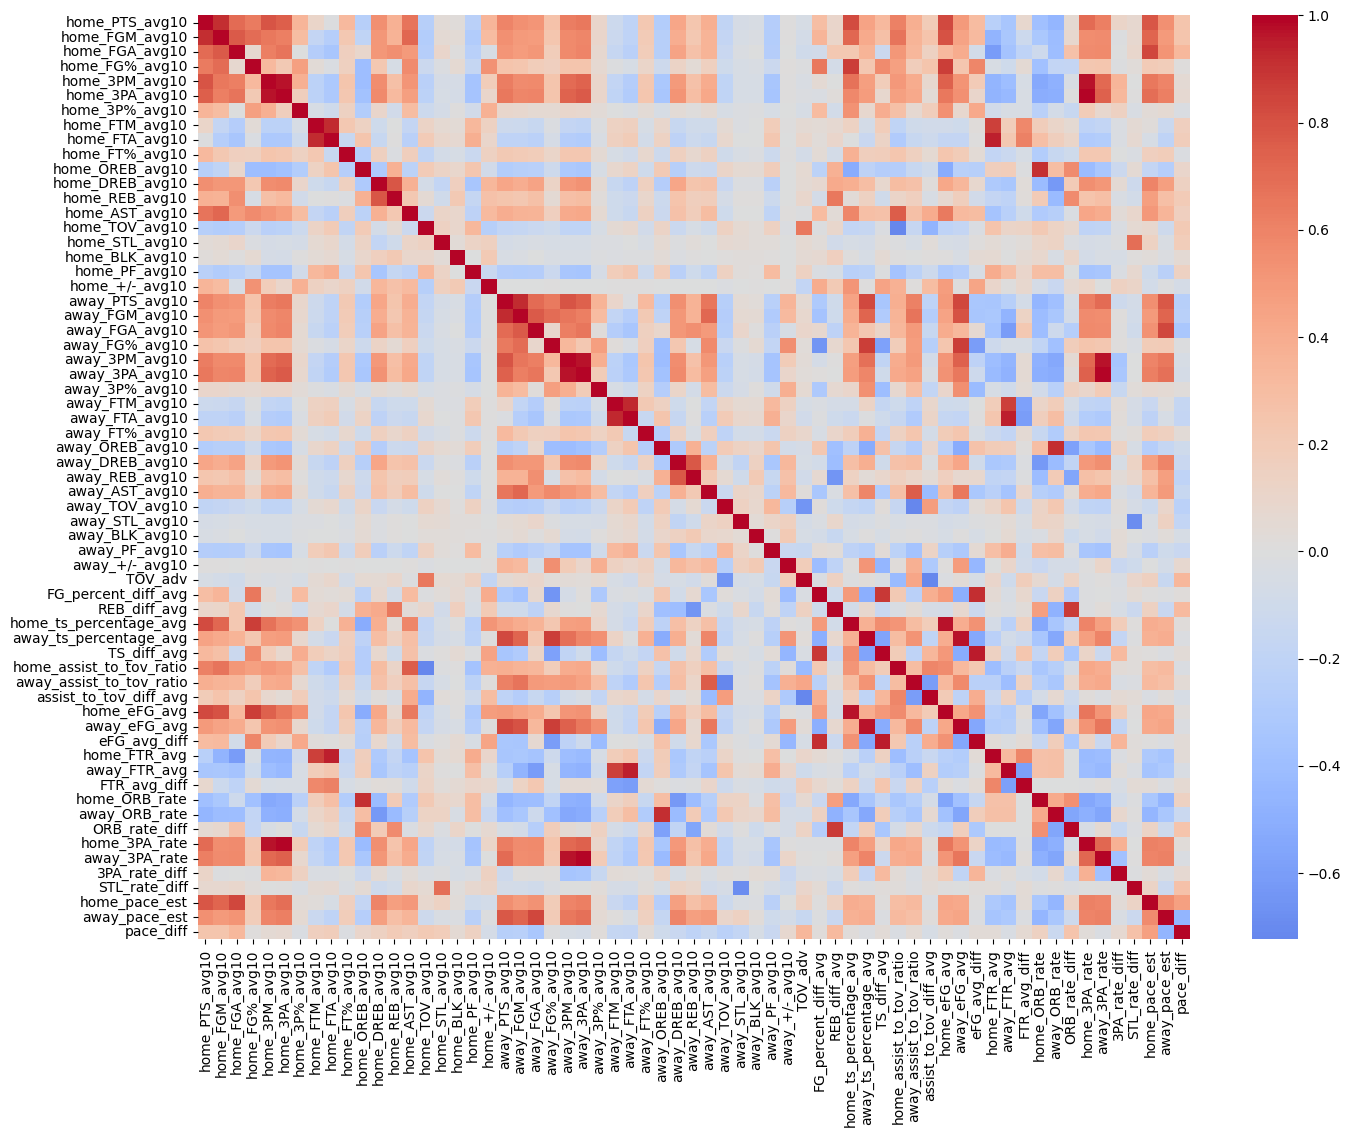

In [294]:
corr = df_merged.drop(columns=["season"]).corr(numeric_only=True)
high_corr = []

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

high_corr = []
for col1 in corr.columns:
    for col2 in corr.columns:
        if col1 < col2:  # avoid self pairing
            if abs(corr.loc[col1, col2]) > 0.80:
                high_corr.append({
                    "Feature 1": col1,
                    "Feature 2": col2,
                    "Correlation": corr.loc[col1, col2]
                })

# Convert to DataFrame and export to visualize
high_corr_df = pd.DataFrame(high_corr)
high_corr_df = high_corr_df.sort_values(by="Correlation", ascending=False)
high_corr_df
high_corr_df.to_csv("high_correlations.csv", index=False)

Drop highly correlated features and features built into combined features, also dropped `3PA_rate_diff_adj` and `pace_diff_adj` due to leakage in their computation

In [ ]:
drop_cols = [
    "home_FGM_avg10", "home_FGA_avg10", "home_FG%_avg10", "home_PTS_avg10",
    "away_FGM_avg10", "away_FGA_avg10", "away_FG%_avg10", "away_PTS_avg10",

    "home_ts_percentage_avg", "away_ts_percentage_avg",
    "home_eFG_avg", "away_eFG_avg",
    "home_assist_to_tov_ratio", "away_assist_to_tov_ratio",
    "home_FTR_avg", "away_FTR_avg",
    "home_ORB_rate", "away_ORB_rate",

    "home_3PA_rate", "away_3PA_rate",
    "home_pace_est", "away_pace_est",
    "REB_diff_avg",
    "FG_percent_diff_avg", "eFG_avg_diff", "home_3PA_avg10",
    "away_3PA_avg10", "home_FTA_avg10", "away_FTA_avg10",
    "home_FTM_avg10", "away_FTM_avg10", "home_REB_avg10",
    "away_REB_avg10" 
]

df_merged = df_merged.drop(columns=drop_cols)

KeyError: "['3PA_rate_diff_adj'] not found in axis"

Visualize new correlation map

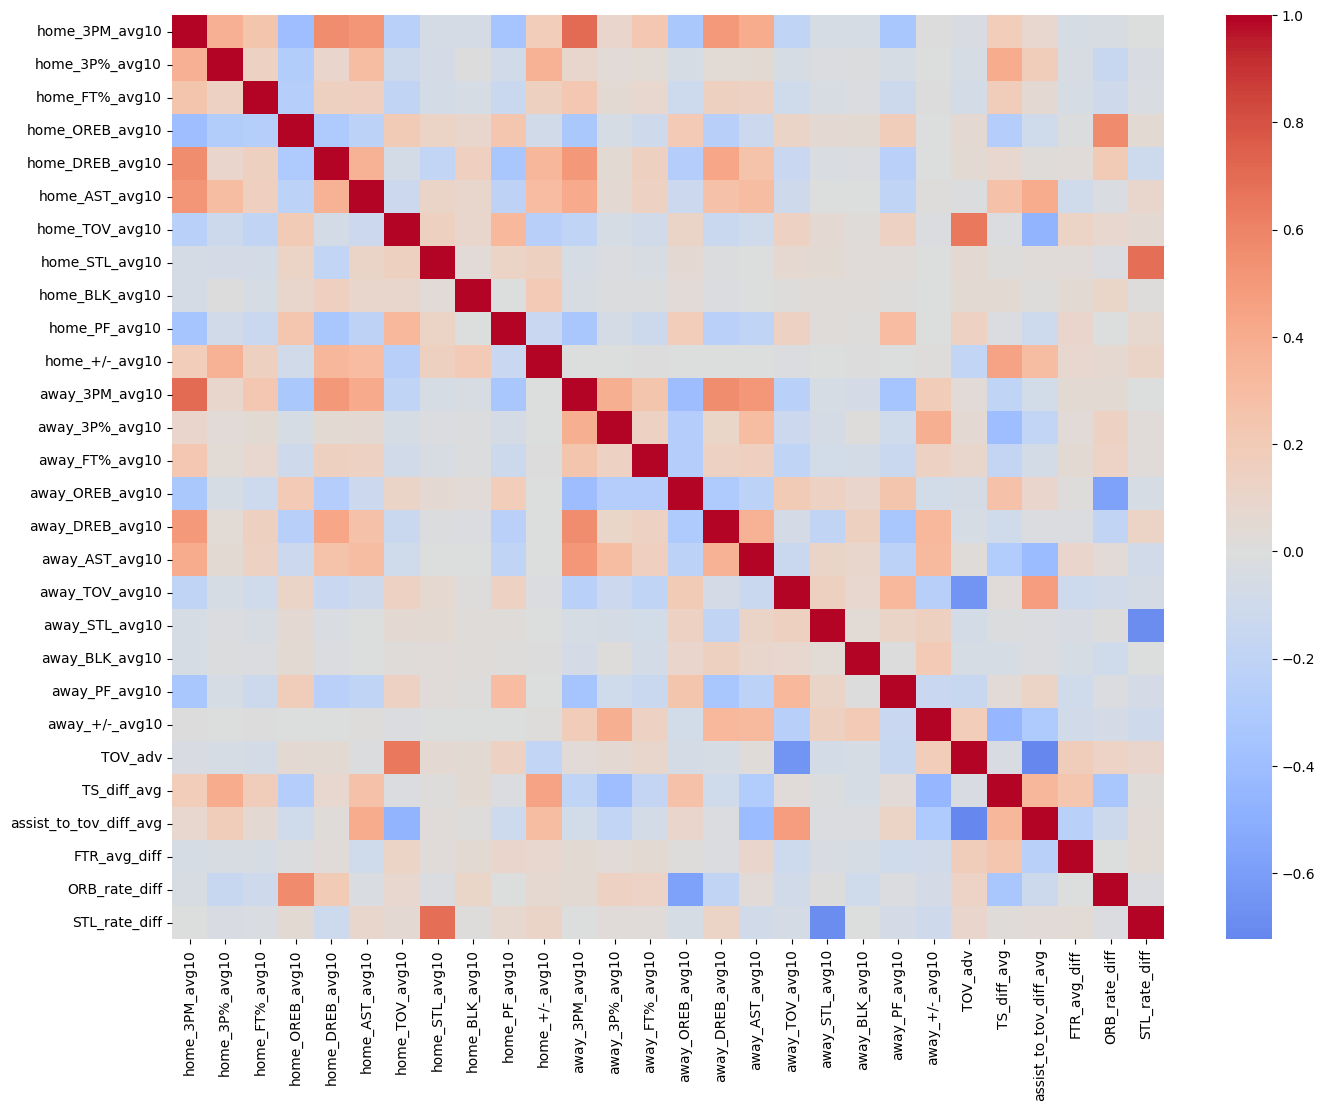

In [ ]:
corr = df_merged.drop(columns=["season"]).corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

In [ ]:
df_merged.columns

Index(['season', 'home_3PM_avg10', 'home_3P%_avg10', 'home_FT%_avg10',
       'home_OREB_avg10', 'home_DREB_avg10', 'home_AST_avg10',
       'home_TOV_avg10', 'home_STL_avg10', 'home_BLK_avg10', 'home_PF_avg10',
       'home_+/-_avg10', 'away_3PM_avg10', 'away_3P%_avg10', 'away_FT%_avg10',
       'away_OREB_avg10', 'away_DREB_avg10', 'away_AST_avg10',
       'away_TOV_avg10', 'away_STL_avg10', 'away_BLK_avg10', 'away_PF_avg10',
       'away_+/-_avg10', 'win_type', 'TOV_adv', 'TS_diff_avg',
       'assist_to_tov_diff_avg', 'FTR_avg_diff', 'ORB_rate_diff',
       'STL_rate_diff'],
      dtype='object')

Examine reformed dataset

In [ ]:
df_merged.head(15)

,season,home_3PM_avg10,home_3P%_avg10,home_FT%_avg10,home_OREB_avg10,home_DREB_avg10,home_AST_avg10,home_TOV_avg10,home_STL_avg10,home_BLK_avg10,...,away_BLK_avg10,away_PF_avg10,away_+/-_avg10,win_type,TOV_adv,TS_diff_avg,assist_to_tov_diff_avg,FTR_avg_diff,ORB_rate_diff,STL_rate_diff
0,1997,5.8,31.66,73.60,12.3,32.4,18.6,19.30,6.9,5.3,...,4.8,24.0,-9.06,home_close_win,0.62,0.007275,-0.096227,0.042657,0.018187,0.5
1,1997,5.7,32.10,69.03,13.7,25.3,21.5,16.40,9.7,5.3,...,4.5,26.4,1.20,away_normal_win,-0.40,-0.049273,0.102642,-0.038672,0.006051,1.4
2,1997,3.9,34.77,77.61,13.7,29.5,19.0,15.20,8.1,4.8,...,5.1,19.0,-1.90,away_normal_win,-1.20,0.036599,0.237805,0.041402,0.036582,0.3
3,1997,8.4,35.91,72.37,13.9,32.3,25.1,19.90,10.0,5.0,...,3.3,24.1,-11.30,home_normal_win,3.90,0.066558,-0.132443,0.108701,0.051224,1.9
4,1997,6.5,36.24,75.53,12.6,31.3,23.5,20.90,6.8,6.0,...,4.2,19.6,20.30,away_normal_win,7.00,-0.030903,-0.832433,0.040166,-0.037885,-1.5
5,1997,5.4,33.54,68.60,14.3,29.7,22.1,14.80,6.7,6.0,...,5.0,22.1,-4.50,home_normal_win,-5.20,-0.020043,0.428243,-0.127546,0.008705,-2.0
6,1997,7.4,38.99,67.91,11.8,28.6,23.1,16.90,7.0,6.2,...,5.9,20.7,-6.70,home_normal_win,1.30,0.067062,0.071992,0.043265,0.011391,-1.8
7,1997,3.6,37.74,70.08,13.2,28.4,19.6,17.82,5.8,4.6,...,5.1,25.8,1.80,away_close_win,1.02,-0.004221,-0.090588,0.010006,0.011976,-2.5
8,1997,7.5,38.23,68.80,15.0,28.2,20.0,21.20,9.3,5.0,...,5.6,27.5,5.10,home_normal_win,-0.40,-0.048356,-0.047345,0.035299,0.026950,1.2
9,1997,7.7,43.28,72.29,11.7,27.2,23.0,15.40,6.3,3.7,...,2.7,19.4,7.70,home_normal_win,0.80,-0.018540,0.288027,0.015567,0.002075,-0.2


Export to new csv

In [ ]:
df_merged.to_csv("extracted_nba_game_data.csv", index=0)

Check win_type imbalance before model training and testing

Class Distribution for win_type:

home_normal_win: 11617 (34.29%)
away_normal_win: 7929 (23.40%)
home_close_win: 4960 (14.64%)
away_close_win: 4333 (12.79%)
home_blowout_win: 3438 (10.15%)
away_blowout_win: 1602 (4.73%)

Imbalance Ratio (max:min) = 7.25:1
⚠️ Severe class imbalance detected


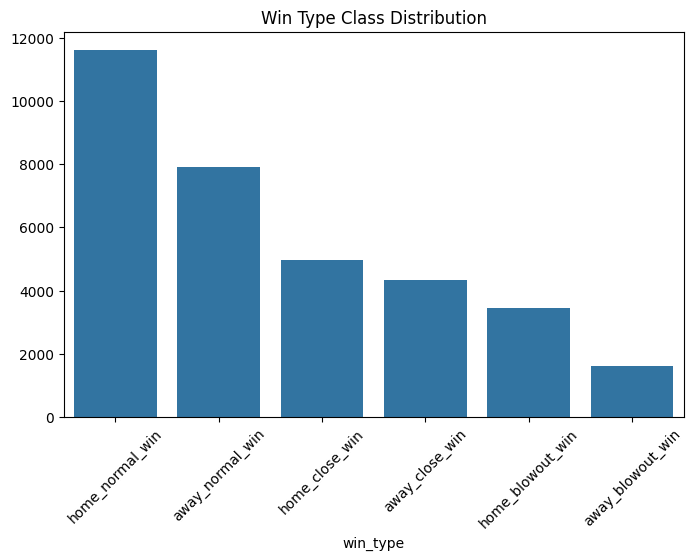

In [ ]:
# Visualize win_type class counts to see imbalance
win_type_count = df_merged["win_type"].value_counts()
win_type_percent = df_merged["win_type"].value_counts(normalize=True) * 100

print("Class Distribution for win_type:\n")
for cls in win_type_count.index:
    print(f"{cls}: {win_type_count[cls]} ({win_type_percent[cls]:.2f}%)")

# Calculate imbalance ratio
minority_class = win_type_count.min()
majority_class = win_type_count.max()
imbalance_ratio = majority_class / minority_class

print(f"\nImbalance Ratio (max:min) = {imbalance_ratio:.2f}:1")

if imbalance_ratio > 5:
    print("⚠️ Severe class imbalance detected")
elif imbalance_ratio > 3:
    print("⚠️ Significant class imbalance detected")
elif imbalance_ratio > 1.5:
    print("⚠️ Moderate class imbalance detected")
else:
    print("No significant class imbalance")

plt.figure(figsize=(8,5))
sns.barplot(x=win_type_count.index, y=win_type_count.values)
plt.xticks(rotation=45)
plt.title("Win Type Class Distribution")
plt.show()


Handle target class imbalance by adding weights to avoid distorting data and treat classes fairly. Move to over and under sampling if minority classes are still predicted poorly.

## Feature analysis

KeyError: '3PA_rate_diff'

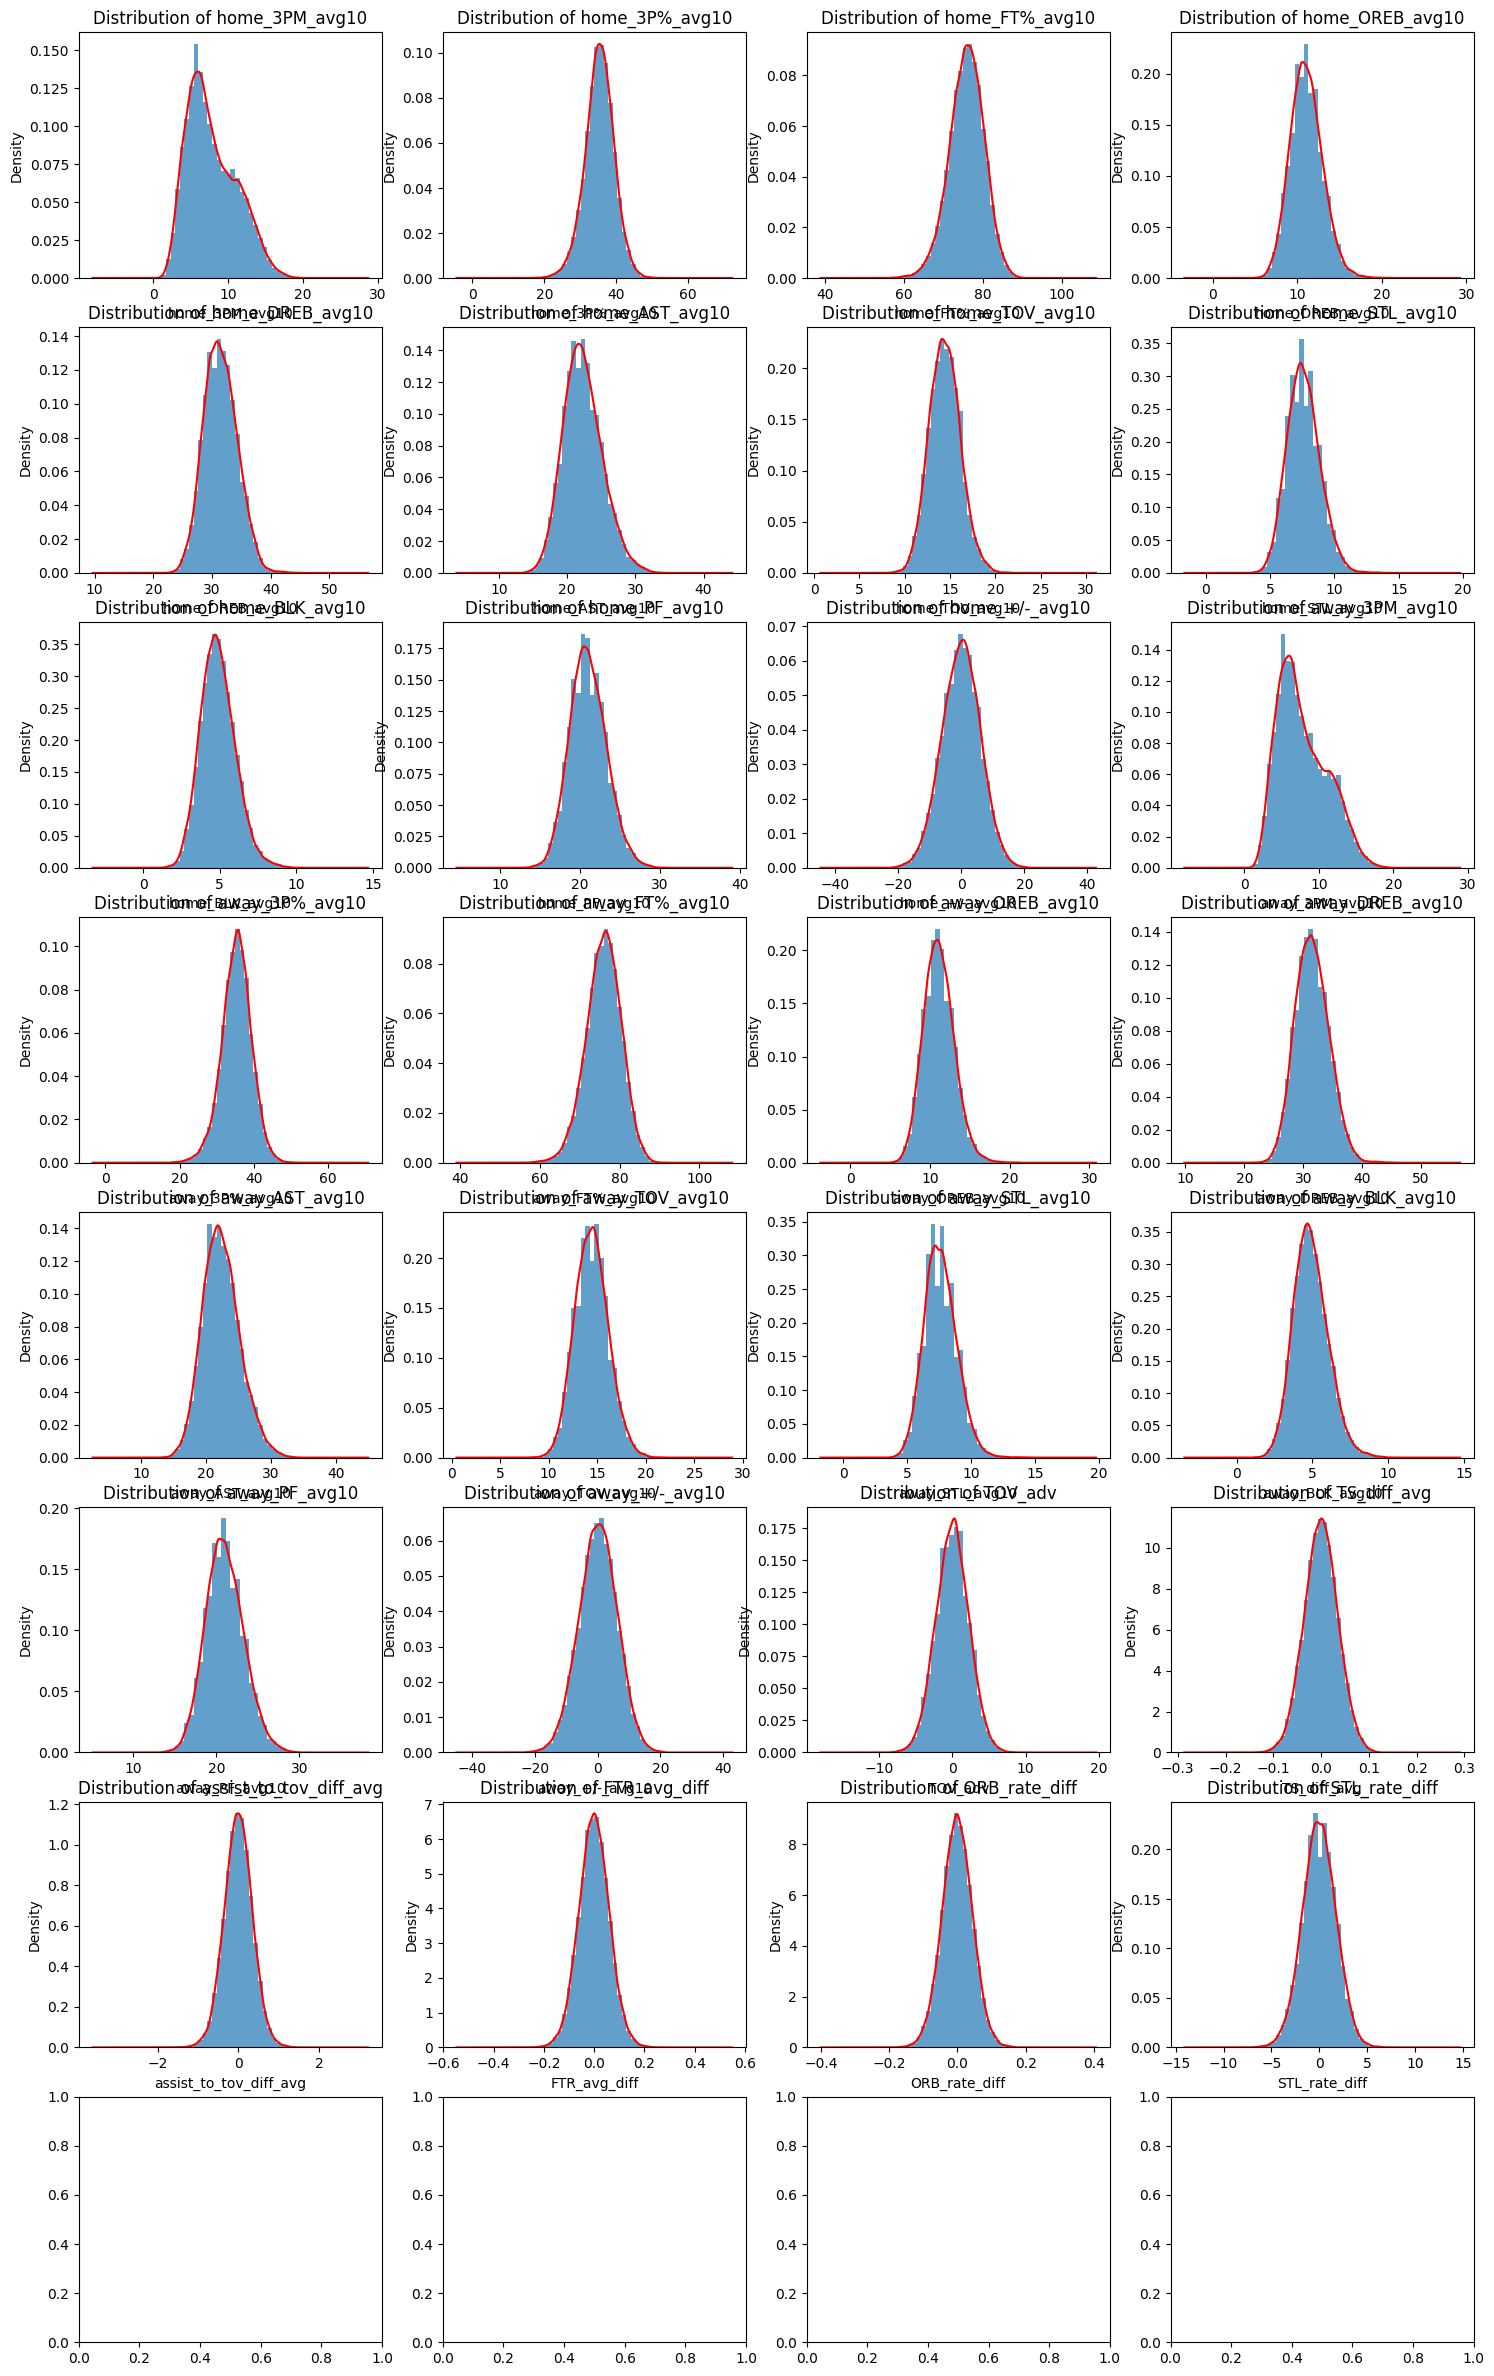

In [ ]:
numerical_cols = [
    'home_3PM_avg10', 'home_3P%_avg10', 'home_FT%_avg10',
    'home_OREB_avg10', 'home_DREB_avg10', 'home_AST_avg10',
    'home_TOV_avg10', 'home_STL_avg10', 'home_BLK_avg10',
    'home_PF_avg10', 'home_+/-_avg10', 
    'away_3PM_avg10', 'away_3P%_avg10', 'away_FT%_avg10',
    'away_OREB_avg10', 'away_DREB_avg10', 'away_AST_avg10',
    'away_TOV_avg10', 'away_STL_avg10', 'away_BLK_avg10',
    'away_PF_avg10', 'away_+/-_avg10',
    'TOV_adv', 'TS_diff_avg', 'assist_to_tov_diff_avg',
    'FTR_avg_diff', 'ORB_rate_diff', 'STL_rate_diff', "3PA_rate_diff", "pace_diff"
] # leave out season becuase it's not used for prediction

fig, axes = plt.subplots(8, 4, figsize=(18, 30)) 
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df_merged[col], bins=30, alpha=0.7, density=True)
    df_merged[col].plot(kind='kde', ax=axes[i], color='red')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

print("Statistical Summary for Numerical Variables:")
print(df_merged[numerical_cols].describe())

`Analysis`: 

- 3PM_avg_10 has a higher variance than other features, could be a strong predictor for blowout wins. 
- No aparent impossible values e.g above 60 percent **3P** shooting percentage or negative stat values

## Final feature selecton 

- Use **Mutual information** to measure which features are strongly associated with `win_type`

- Mutual Information captures both linear and non linear relationships between features

In [ ]:
X = df_merged.drop(columns=["season", "win_type"])
y = df_merged["win_type"]

# Calculate mutual information
mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print("Mutual Information table:\n")
print(mi_series)
best_features = mi_series.index.tolist()
print(best_features)

Mutual Information table:

home_+/-_avg10            0.035475
away_+/-_avg10            0.028124
TS_diff_avg               0.025349
3PA_rate_diff             0.013603
assist_to_tov_diff_avg    0.010997
TOV_adv                   0.008609
away_PF_avg10             0.008290
away_3P%_avg10            0.008187
away_TOV_avg10            0.007979
away_AST_avg10            0.007932
away_OREB_avg10           0.005947
home_STL_avg10            0.005437
home_3PM_avg10            0.003479
away_DREB_avg10           0.003334
away_3PM_avg10            0.003108
home_FT%_avg10            0.002821
home_3P%_avg10            0.002648
home_DREB_avg10           0.002350
away_STL_avg10            0.001701
home_PF_avg10             0.001505
ORB_rate_diff             0.000900
home_BLK_avg10            0.000773
away_BLK_avg10            0.000108
away_FT%_avg10            0.000000
home_TOV_avg10            0.000000
home_AST_avg10            0.000000
home_OREB_avg10           0.000000
FTR_avg_diff              0.

Selected these featues for modeling because they had high MI scores when compared with `win_type` the top features in this list should lead to better results in model training and testing.

## Model Testing

Start with a simple decision tree

              precision    recall  f1-score   support

           0       0.06      0.07      0.06       320
           1       0.12      0.13      0.12       867
           2       0.26      0.25      0.26      1586
           3       0.14      0.14      0.14       688
           4       0.15      0.15      0.15       992
           5       0.36      0.34      0.35      2323

    accuracy                           0.23      6776
   macro avg       0.18      0.18      0.18      6776
weighted avg       0.24      0.23      0.24      6776



<Figure size 1000x800 with 0 Axes>

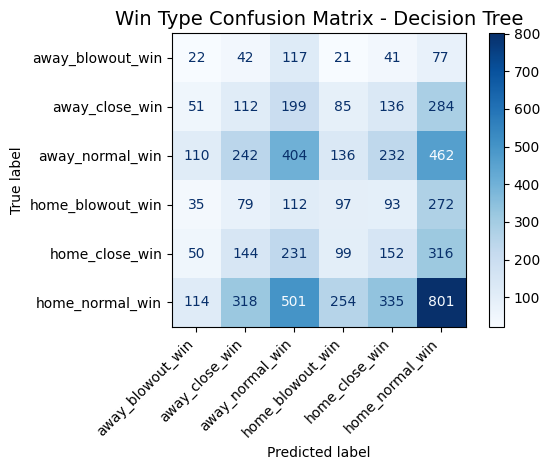

In [ ]:
X = df_merged[best_features[0:11]]
y = df_merged["win_type"]

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded 
)

# Start with decision tree
d_tree = DecisionTreeClassifier(criterion='entropy',class_weight='balanced', random_state=42) # balanced class weight as first attempt to account for imbalance in win_type
d_tree.fit(X_train, y_train)

d_tree_pred = d_tree.predict(X_test)
print(classification_report(y_test, d_tree_pred))

plt.figure(figsize=(10, 8))  

cm = confusion_matrix(y_test, d_tree_pred)
class_names = le.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Win Type Confusion Matrix - Decision Tree", fontsize=14)
plt.tight_layout()  
plt.show()

`Analysis`: 
- The decision tree overpredicts the two most common classes `home_normal_win` and `away_normal_win`
- Almost every class has their highest predicted class as `home_normal_win` showing that the class imbalance which was attempted to be fixed by the class_weight parameter was not very effective.
- Extremely low F1 scores in all classes

Try different algorithms and then sampling if class imbalance continues to be an issue.

              precision    recall  f1-score   support

           0       0.14      0.09      0.11       320
           1       0.14      0.08      0.10       867
           2       0.30      0.46      0.36      1586
           3       0.21      0.18      0.19       688
           4       0.15      0.07      0.09       992
           5       0.40      0.45      0.42      2323

    accuracy                           0.30      6776
   macro avg       0.22      0.22      0.21      6776
weighted avg       0.27      0.30      0.28      6776



<Figure size 1000x800 with 0 Axes>

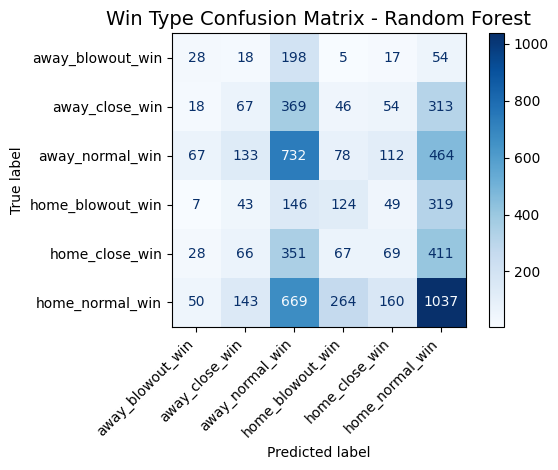

In [ ]:
# Try random forest algorithm
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print(classification_report(y_test, rf_pred))

plt.figure(figsize=(10, 8))  

cm = confusion_matrix(y_test, rf_pred)
class_names = le.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Win Type Confusion Matrix - Random Forest", fontsize=14)
plt.tight_layout()  
plt.show()

`Analysis`: 
- Slight improvement from a singular decision tree but class imbalance persists as a major issue. I'll use random oversmapling to duplicate real game data from the minority classes so that the model learns on real data from the dataset instead of synthetic data that would be created from using methods like SMOTE.

## Address imbalance

- Use random oversampling 

In [ ]:
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

original_counts = pd.Series(y_train).value_counts()
resampled_counts = pd.Series(y_train_res).value_counts()

# Print class distributions
print("Original class distribution:")
print(original_counts)

print("\nAfter Random over sampling:")
print(resampled_counts)

Original class distribution:
5    9294
2    6343
4    3968
1    3466
3    2750
0    1282
Name: count, dtype: int64

After Random over sampling:
5    9294
4    9294
2    9294
3    9294
1    9294
0    9294
Name: count, dtype: int64


Retrain random forest model

                  precision    recall  f1-score   support

away_blowout_win       0.14      0.13      0.13       320
  away_close_win       0.15      0.11      0.12       867
 away_normal_win       0.30      0.42      0.35      1586
home_blowout_win       0.20      0.22      0.21       688
  home_close_win       0.16      0.10      0.12       992
 home_normal_win       0.40      0.38      0.39      2323

        accuracy                           0.29      6776
       macro avg       0.22      0.23      0.22      6776
    weighted avg       0.28      0.29      0.28      6776



<Figure size 1000x800 with 0 Axes>

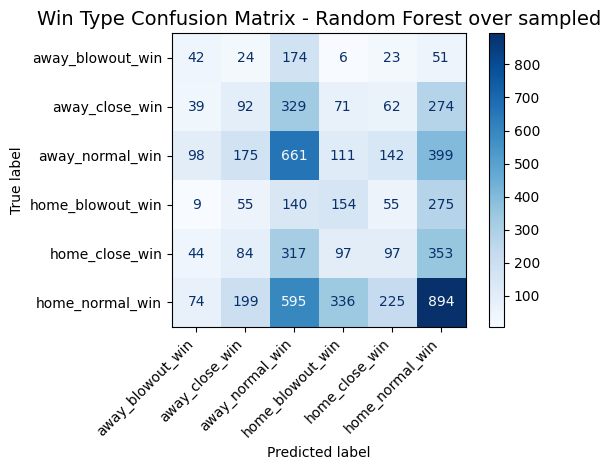

In [ ]:
rf_oversampled = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_oversampled.fit(X_train_res, y_train_res)

y_pred = rf_oversampled.predict(X_test) 
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(10, 8))  

cm = confusion_matrix(y_test, y_pred)
class_names = le.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Win Type Confusion Matrix - Random Forest over sampled", fontsize=14)
plt.tight_layout()  
plt.show()

Random over sampling actually made the mode performance slightly better in the f1 score for the minority class but did not improve the model significantly. The duplicate samples likely caused the random forest model overfit to those sampled games and it led to poor testing performance.   

Try XGBoost 

              precision    recall  f1-score   support

           0       0.12      0.21      0.15       320
           1       0.13      0.14      0.13       867
           2       0.31      0.31      0.31      1586
           3       0.16      0.24      0.19       688
           4       0.15      0.15      0.15       992
           5       0.40      0.30      0.34      2323

    accuracy                           0.25      6776
   macro avg       0.21      0.22      0.21      6776
weighted avg       0.27      0.25      0.26      6776



<Figure size 1000x800 with 0 Axes>

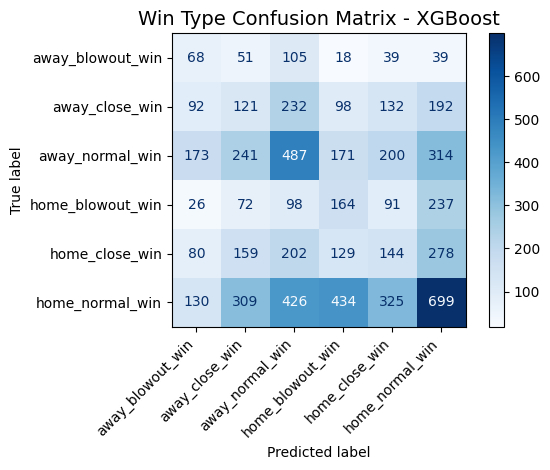

In [ ]:
xgb_model = XGBClassifier(
    eval_metric='logloss', 
    random_state=42, 
    objective="multi:softmax",
    num_class=6,
    n_jobs=-1
)

xgb_model.fit(X_train_res, y_train_res)
xgb_pred = xgb_model.predict(X_test)
print(classification_report(y_test, xgb_pred))

plt.figure(figsize=(10, 8))  

cm = confusion_matrix(y_test, xgb_pred)
class_names = le.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Win Type Confusion Matrix - XGBoost", fontsize=14)
plt.tight_layout()  
plt.show()

- XGBoost did not do as well as the random forest model likely due to the over sampling. XGBoost tries to correct the errors of the previous tree and doning that on oversampled samples can lead to overfitting which will lead to worse performance on testing. Class imbalance remains the primary problem so I will try random undersampling to address this instead.

## Random Undersampling

In [ ]:
rus = RandomUnderSampler(
    sampling_strategy='auto',  # Reduce majority classes to match minority class
    random_state=42
)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

original_counts = pd.Series(y_train).value_counts()
resampled_counts = pd.Series(y_train_rus).value_counts()

# Print class distributions
print("Original class distribution:")
print(original_counts)

print("\nAfter Random under sampling:")
print(resampled_counts)

Original class distribution:
5    9294
2    6343
4    3968
1    3466
3    2750
0    1282
Name: count, dtype: int64

After Random under sampling:
0    1282
1    1282
2    1282
3    1282
4    1282
5    1282
Name: count, dtype: int64


- Train model on undersampled data and predict

              precision    recall  f1-score   support

           0       0.10      0.37      0.15       320
           1       0.14      0.18      0.16       867
           2       0.27      0.17      0.21      1586
           3       0.16      0.30      0.21       688
           4       0.16      0.17      0.16       992
           5       0.40      0.18      0.25      2323

    accuracy                           0.20      6776
   macro avg       0.21      0.23      0.19      6776
weighted avg       0.26      0.20      0.21      6776



<Figure size 1000x800 with 0 Axes>

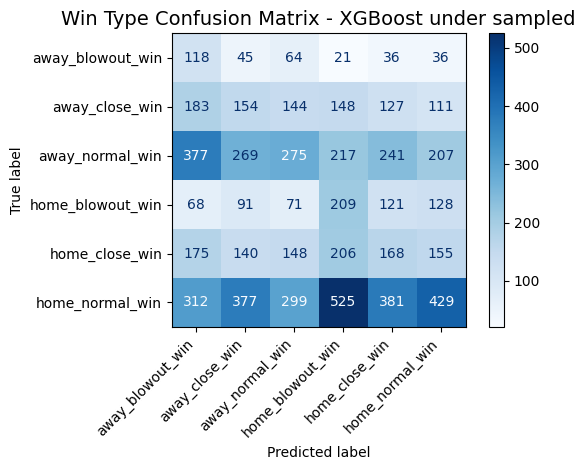

In [ ]:
xgb_model.fit(X_train_rus, y_train_rus)
xgb_pred = xgb_model.predict(X_test)
print(classification_report(y_test, xgb_pred))

plt.figure(figsize=(10, 8))  

cm = confusion_matrix(y_test, xgb_pred)
class_names = le.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Win Type Confusion Matrix - XGBoost under sampled", fontsize=14)
plt.tight_layout()  
plt.show()

Undersampling gave the minority classes better results than oversampling but provided worse overall results than oversampling suggesting that oversampling is the better technique in this case but still not very effective in significantly reducing the affect of class imbalance for this task.

## Grid search

Hyperparameter tuning is done on raw (non-resampled) X_train. Resampling is excluded from the grid search so that cross-validation folds are split before any oversampling. This prevents duplicated minority rows from leaking across the train/validation boundary and inflating CV scores. Class imbalance is handled inside the search by scoring on f1_macro, to weigh all classes equally, and per-sample balanced weights passed to fit. The final model is refit and reported on raw data to maintain consistency.

In [ ]:
%%time
param_grid = {
    'n_estimators': [200, 400],           
    'max_depth': [10, 20],                 
    'learning_rate': [0.01, 0.1],         
    'subsample': [0.8, 1.0],              
    'colsample_bytree': [1.0],       
    'gamma': [0],                      
    'min_child_weight': [1, 3]             
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_macro',  # since classes are imbalanced score on macro f1
    cv=3,
    verbose=2,
    n_jobs=-1,
    refit=True
)

sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
grid_search_xgb.fit(X_train, y_train, sample_weight=sample_weight)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=10, min_child_weight=1, n_estimators=200, subsample=1.0; total time=  12.5s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=10, min_child_weight=1, n_estimators=200, subsample=0.8; total time=  12.5s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=10, min_child_weight=1, n_estimators=200, subsample=0.8; total time=  12.9s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=10, min_child_weight=1, n_estimators=200, subsample=1.0; total time=  13.0s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=10, min_child_weight=1, n_estimators=200, subsample=0.8; total time=  13.4s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=10, min_child_weight=1, n_estimators=200, subsample=1.0; total time=  13.5s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max

/Users/joshuainordee/Desktop/cs4783/eda_dp/eda_venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   7.6s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=20, min_child_weight=3, n_estimators=400, subsample=1.0; total time=  52.2s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=20, min_child_weight=3, n_estimators=400, subsample=1.0; total time=  52.8s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   6.8s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, n_estimators=400, subsample=0.8; total time=  16.3s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   6.8s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.1, max_depth=10, min_child_weight=1, n_estimators=400, subsample=1.0; to

,estimator,"XGBClassifier..._class=6, ...)"
,param_grid,"{'colsample_bytree': [1.0], 'gamma': [0], 'learning_rate': [0.01, 0.1], 'max_depth': [10, 20], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softmax'


In [ ]:
# Best params
print("Best parameters found:", grid_search_xgb.best_params_)
print("Best F1 macro score:", grid_search_xgb.best_score_)

Best parameters found: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 1.0}
Best F1 macro score: 0.21995256746245237


              precision    recall  f1-score   support

           0       0.10      0.23      0.14       320
           1       0.13      0.13      0.13       867
           2       0.30      0.29      0.30      1586
           3       0.17      0.30      0.22       688
           4       0.18      0.15      0.16       992
           5       0.39      0.28      0.32      2323

    accuracy                           0.24      6776
   macro avg       0.21      0.23      0.21      6776
weighted avg       0.27      0.24      0.25      6776



<Figure size 1000x800 with 0 Axes>

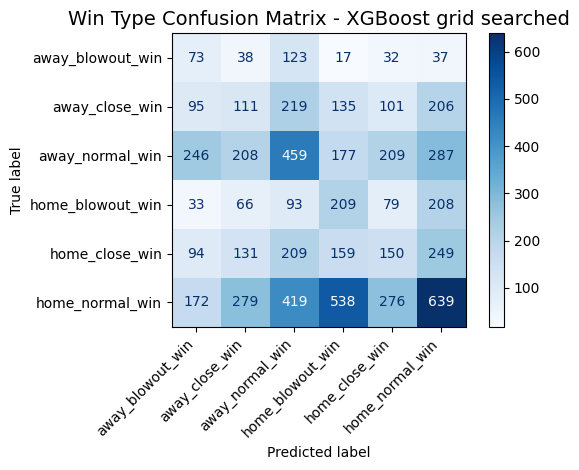

In [ ]:
best_xgb = grid_search_xgb.best_estimator_
xgb_pred = best_xgb.predict(X_test)
print(classification_report(y_test, xgb_pred))

plt.figure(figsize=(10, 8))  

cm = confusion_matrix(y_test, xgb_pred)
class_names = le.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Win Type Confusion Matrix - XGBoost grid searched", fontsize=14)
plt.tight_layout()  
plt.show()

In [ ]:
with open("best_xgb_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)

In [ ]:
# Load model
with open("best_xgb_model.pkl", "rb") as f:
    best_xgb_loaded = pickle.load(f)

print(best_xgb_loaded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1, num_class=6, ...)


XGBoost with grid search naively increased the accuracy due to it prefdicting the majority class correctly more often but the f1 scores for the minority class decreaed suggesting that the model performed worse at picking up the minority class games which were `away_blowout_win` and `home_blowout_win`. Will try a neural network with class weights to see if it can achieve better results

## Deep learning algorithm

- Neural network with relu activation function

Class weights: {np.int64(0): np.float64(3.5235309412376496), np.int64(1): np.float64(1.3032794768224658), np.int64(2): np.float64(0.712149876504283), np.int64(3): np.float64(1.6426060606060606), np.int64(4): np.float64(1.1383988575268817), np.int64(5): np.float64(0.4860304138870956)}
Epoch 1/200


/Users/joshuainordee/Desktop/cs4783/eda_dp/eda_venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1675 - loss: 1.7304 - val_accuracy: 0.1523 - val_loss: 1.7441
Epoch 2/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1667 - loss: 1.7121 - val_accuracy: 0.1494 - val_loss: 1.7419
Epoch 3/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1655 - loss: 1.7093 - val_accuracy: 0.1704 - val_loss: 1.7279
Epoch 4/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1817 - loss: 1.7056 - val_accuracy: 0.1667 - val_loss: 1.7391
Epoch 5/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1842 - loss: 1.7050 - val_accuracy: 0.1723 - val_loss: 1.7450
Epoch 6/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1849 - loss: 1.7028 - val_accuracy: 0.1534 - val_loss: 1.7560
Epoch 7/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1788 - loss: 1.7009 - val_accuracy: 0.1457 - val_loss: 1.7366
Epoch 8/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1703 - loss: 1.6982 - val_accuracy: 0.1623

<Figure size 1000x800 with 0 Axes>

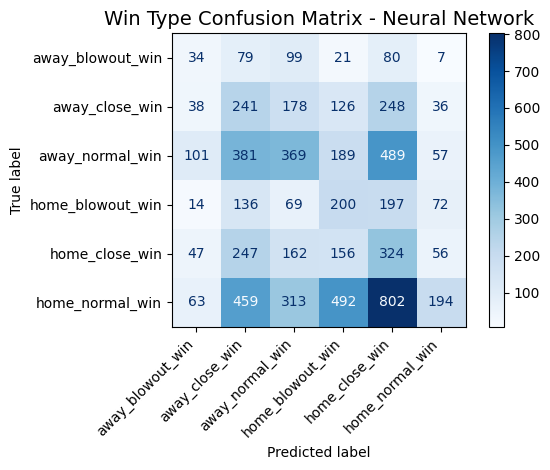

Macro F1: 0.18966341861574762
Weighted F1: 0.19346323226602624


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Compute class weights to help imbalance
classes = np.unique(y_train)
class_weights_values = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights_values))
print("Class weights:", class_weights)

# Build model
input_dim = X_train.shape[1]
num_classes = 6

model = keras.models.Sequential()

# Input layer
model.add(keras.layers.Dense(512, activation="relu", input_shape=(input_dim,)))

# Sizes for the next 8 hidden layers
hidden_sizes = [256, 256, 128, 128, 64, 64, 32, 32]

# Add hidden layers
for i, size in enumerate(hidden_sizes):
    model.add(keras.layers.Dense(size, activation="relu"))
    if i < 4:   # Add dropout in first few layers to help prevent overfitting
        model.add(keras.layers.Dropout(0.2))

# Output layer
model.add(keras.layers.Dense(num_classes, activation="softmax"))

adam_optimizer = Adam(
    learning_rate=0.001,   
    beta_1=0.85,          
    beta_2=0.995,      
    epsilon=1e-7
)

# Compile model
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=adam_optimizer,
    #optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)


# train mmodel
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=200,               
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=1
)

# evaluate
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(10, 8))  

cm = confusion_matrix(y_test, y_pred)
class_names = le.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Win Type Confusion Matrix - Neural Network", fontsize=14)
plt.tight_layout()  
plt.show()

macro_f1 = f1_score(y_test, y_pred, average='macro')   
weighted_f1 = f1_score(y_test, y_pred, average='weighted')  
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Try leaky relu

Class weights: {np.int64(0): np.float64(3.5235309412376496), np.int64(1): np.float64(1.3032794768224658), np.int64(2): np.float64(0.712149876504283), np.int64(3): np.float64(1.6426060606060606), np.int64(4): np.float64(1.1383988575268817), np.int64(5): np.float64(0.4860304138870956)}
Epoch 1/200


/Users/joshuainordee/Desktop/cs4783/eda_dp/eda_venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/joshuainordee/Desktop/cs4783/eda_dp/eda_venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1444 - loss: 1.7235 - val_accuracy: 0.1464 - val_loss: 1.7539
Epoch 2/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1543 - loss: 1.7063 - val_accuracy: 0.1461 - val_loss: 1.7534
Epoch 3/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1664 - loss: 1.7035 - val_accuracy: 0.1660 - val_loss: 1.7367
Epoch 4/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1707 - loss: 1.7012 - val_accuracy: 0.1605 - val_loss: 1.7530
Epoch 5/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1739 - loss: 1.6988 - val_accuracy: 0.1557 - val_loss: 1.7580
Epoch 6/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1776 - loss: 1.6969 - val_accuracy: 0.1571 - val_loss: 1.7527
Epoch 7/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1793 - loss: 1.6947 - val_accuracy: 0.1630 - val_loss: 1.7418
Epoch 8/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1744 - loss: 1.6912 - val_accuracy: 0.1472

<Figure size 1000x800 with 0 Axes>

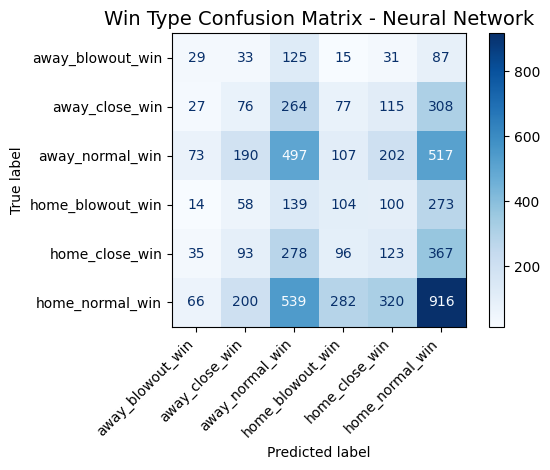

Macro F1: 0.1929935965715368
Weighted F1: 0.25119099044769483


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classes = np.unique(y_train)
class_weights_values = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights_values))
print("Class weights:", class_weights)

input_dim = X_train.shape[1]
num_classes = 6

model = keras.models.Sequential()

# Input layer with Leaky ReLU
model.add(layers.Dense(512, input_shape=(input_dim,)))
model.add(layers.LeakyReLU(alpha=0.01))  

hidden_sizes = [256, 256, 128, 128, 64, 64, 32, 32]

# Add hidden layers with Leaky ReLU
for size in hidden_sizes:
    model.add(layers.Dense(size))
    model.add(layers.LeakyReLU(alpha=0.01))

# Output layer
model.add(layers.Dense(num_classes, activation="softmax"))

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)


history = model.fit(
    X_train_scaled,
    y_train,
    epochs=200,               
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(10, 8))  

cm = confusion_matrix(y_test, y_pred)
class_names = le.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Win Type Confusion Matrix - Neural Network", fontsize=14)
plt.tight_layout()  
plt.show()

macro_f1 = f1_score(y_test, y_pred, average='macro')  
weighted_f1 = f1_score(y_test, y_pred, average='weighted') 
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)


Try exponential relu

Class weights: {np.int64(0): np.float64(3.5235309412376496), np.int64(1): np.float64(1.3032794768224658), np.int64(2): np.float64(0.712149876504283), np.int64(3): np.float64(1.6426060606060606), np.int64(4): np.float64(1.1383988575268817), np.int64(5): np.float64(0.4860304138870956)}
Epoch 1/200


/Users/joshuainordee/Desktop/cs4783/eda_dp/eda_venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1866 - loss: 1.7356 - val_accuracy: 0.1638 - val_loss: 1.7685
Epoch 2/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1772 - loss: 1.7206 - val_accuracy: 0.1612 - val_loss: 1.7524
Epoch 3/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1819 - loss: 1.7165 - val_accuracy: 0.1549 - val_loss: 1.7460
Epoch 4/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1811 - loss: 1.7138 - val_accuracy: 0.1734 - val_loss: 1.7424
Epoch 5/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1851 - loss: 1.7117 - val_accuracy: 0.1734 - val_loss: 1.7425
Epoch 6/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1858 - loss: 1.7102 - val_accuracy: 0.1564 - val_loss: 1.7517
Epoch 7/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1864 - loss: 1.7097 - val_accuracy: 0.1616 - val_loss: 1.7454
Epoch 8/200
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1852 - loss: 1.7088 - val_accuracy: 0.1649

<Figure size 1000x800 with 0 Axes>

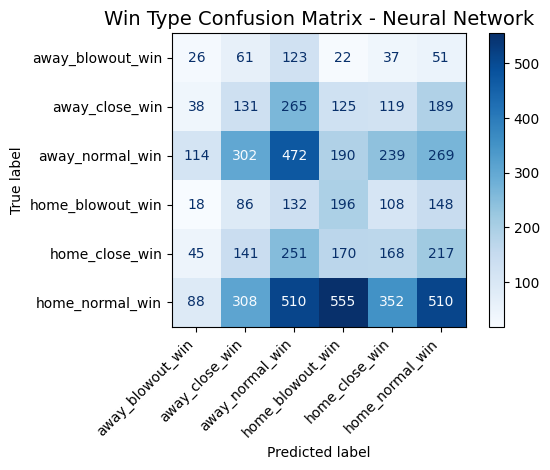

Macro F1: 0.19072860635920266
Weighted F1: 0.22683441220114914


In [180]:
np.random.seed(42)
tf.random.set_seed(42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classes = np.unique(y_train)
class_weights_values = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights_values))
print("Class weights:", class_weights)

input_dim = X_train.shape[1]
num_classes = 6

model = keras.models.Sequential()

# Input layer with ELU
model.add(layers.Dense(512, input_shape=(input_dim,)))
model.add(layers.ELU(alpha=1.0))  

hidden_sizes = [256, 256, 128, 128, 64, 64, 32, 32]

# Add hidden layers with ELU
for size in hidden_sizes:
    model.add(layers.Dense(size))
    model.add(layers.ELU(alpha=1.0))

# Output layer
model.add(layers.Dense(num_classes, activation="softmax"))

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=200,               
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=1
)

# Evaluate
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(10, 8))  

cm = confusion_matrix(y_test, y_pred)
class_names = le.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Win Type Confusion Matrix - Neural Network", fontsize=14)
plt.tight_layout()  
plt.show()

macro_f1 = f1_score(y_test, y_pred, average='macro')   
weighted_f1 = f1_score(y_test, y_pred, average='weighted')  
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Neural network model does not do better than the tree based machine learning models from earlier. There's a slight improvement in predicting `away_normal_win` but other than that the neural network performed relatively the same compared to the previous models with the XGBoost performing the best. I experimented with different epoch values and layer counts. Anything past 8 hidden layers had diminishing returns and anything past 200 epochs had drop off as well. I also experimented with leaky relu and exponential relu and did not see meaningful changes. Changing the velocity parameters for Adam gradient descent on the regular relU also did not affect model performance significantly. Adding a dropout in the first few layers to turn off 20% of the neurons in the first few layers to try and prevent overfiitting actuall caused the model to underfit and not learn enough so I didn't use it in the subsequent models where i experimented with different activation functions.

- My overall take away from this project is that class imbalance plays a significant factor in model performance especially for a project like this, and when techniques used to help supplement that don't work it's hard to get good results. Classifying into six different classes is also difficult to do with an imbalanced dataset as well. Looking into the actual project scope itself it's clear that simple box score averages from previous games do not give major insight into the outcome of future games. Perhaps stats such as star player performances and frequency of games played up until that point such as back to back games might paint a clearer picture for the model to make more accurate predictions. Overall I'd say i've learned a lot from this project and will continue experimenting with different methods to try and reach better results than the ones shown here.